<a href="https://colab.research.google.com/github/Millenes2/Millenes2/blob/main/hash1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tabela Hash (Tabela de Dispersão)**
**Tabela hash** é uma estrutura de dados clássica que promete tempo constante (O(1)) para busca e inserção.
Você pode ter ouvido os termos *Dicionário*, *Hash Map*, *Tabela de Dispersão*, mas todos eles serão tratados como **Tabela Hash** nesta tarefa, já que são praticamente a mesma coisa.

Essencialmente, uma **Tabela Hash** é uma série de pares chave-valor, sendo que a chave é usada para encontrar a posição onde os dados devem ser armazenados (durante a inserção), e o valor contém os dados reais.

Na figura a seguir, temos os pares ***(pessoa, telefone)*** para realizar o espalhamento. Cada nome de ***pessoa*** (campo chave) deverá ser associado à uma posição da tabela para que o ***telefone*** seja ali armazenado.

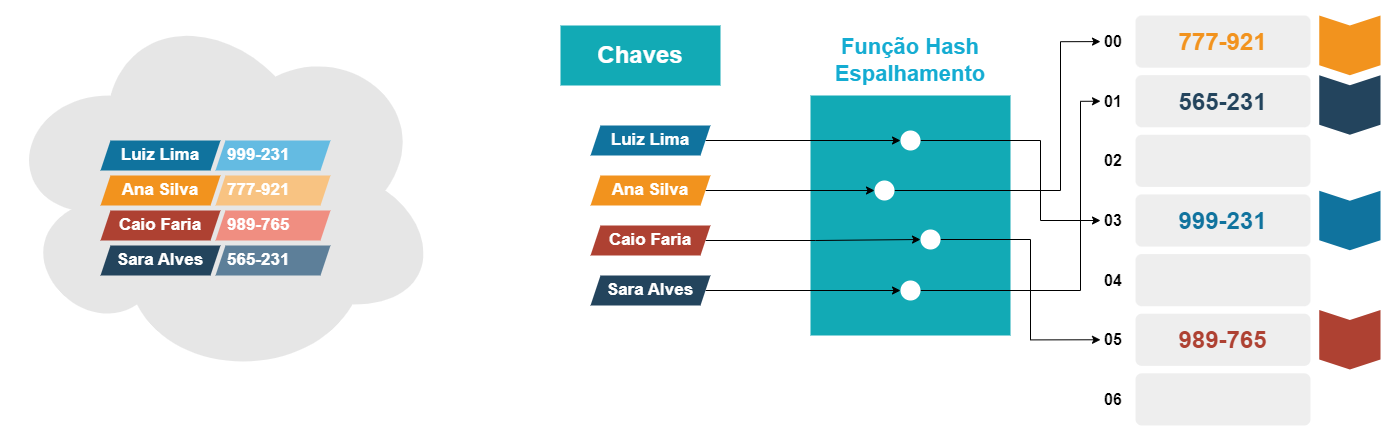

Desta forma, temos as seguintes associações:



```
Luiz Lima -> 03
Ana Silva -> 00
Caio Faria -> 05
Sara Alves -> 01
```



Esta associação é feita a partir de uma **função Hash**, que determina como os elementos serão espalhados. `Luiz Lima` deverá ficar na posição `03`, e assim por diante.





**Hashing** ou **Função Hash** é a técnica utilizada para, dada uma chave qualquer (tipo string, inteiro, ou até mesmo objetos), calcular um valor de índice inteiro correspondente que indica ao computador onde armazenar/recuperar os dados na estrutura (tabela hash).

A seguir, temos um exemplo de função hash para strings usando a função `ord`.

In [1]:
# Dada uma letra, retornar o número correspondente na tabela ASCII
x = ord("h")
print(x)

104


In [12]:
def teste_hash(palavra):
    # Converte a palavra para minúsculas e ignora espaços antes de somar os valores ASCII
    return sum([ord(letra) for letra in palavra.lower() if letra != ' '])

teste_hash("Luiz Lima")

871

In [3]:
[teste_hash("Luiz Lima"), teste_hash("Ana Silva"), teste_hash("Caio Faria"), teste_hash("Sara Alves")]

[839, 815, 895, 930]

**Exercício 1**: Segundo o resultado acima, teríamos que utilizar a posição `839` como índice (linha da tabela) para inserir o telefone do `Luiz Lima`, e assim sucessivamente. Sabendo disso, reponda: (1 ponto)
1. Porque esta função de espalhamento não é boa?
2. O que aconteceria se tivermos um nome com muitas letras?
3. Que resultado teremos para os nomes "marco" e "carmo"?
4. Que tamanho de lista teríamos que utilizar para os 4 nomes que desejamos armazenar os telefones?

Exercicio 1:

1 = A função de espalhamento não é eficiente porque gera valores de índice muito altos e dispersos (por exemplo, 839, 815, 895, 930). Para usá-los diretamente, seria necessária uma tabela hash excessivamente grande, levando a um grande desperdício de memória, já que a maioria das posições ficaria vazia.

2 = Com nomes mais longos, a soma dos valores ASCII aumentaria ainda mais. Isso intensificaria o problema de precisar de tabelas hash cada vez maiores e mais esparsas.

3 = Para os nomes "marco" e "carmo", a função teste_hash retornaria o mesmo valor. Como a função apenas soma os valores ASCII das letras e ambos os nomes são anagramas, a soma final será idêntica, causando uma colisão de hash.

4 = Considerando os valores de hash gerados (839, 815, 895, 930) para os quatro nomes, seria necessário uma lista com no mínimo 931 posições (de 0 a 930) para acomodar o maior índice. Mesmo assim, a função pode resultar em colisões para outras entradas.

**Exercício 2**: Modifique a função `teste_hash` para que os espaços em branco não sejam utilizados no cálculo da posição de espalhamento. (1 ponto)

In [16]:
def teste_hash(palavra):
    return sum([ord(letra) for letra in palavra if letra != ' '])

teste_hash("Luiz Lima")

807

**Exercício 3**: Modifique a função `teste_hash` para que o cálculo do espalhamento se dê utilizando apenas letras minúsculas. Ou seja, todas as letras deve estar em minúsculas antes do cálculo. (1 ponto)

In [15]:
def teste_hash(palavra):
    # Converte a palavra para minúsculas e ignora espaços antes de somar os valores ASCII
    return sum([ord(letra) for letra in palavra.lower() if letra != ' '])

teste_hash("Luiz Lima")

871

**Exercício 4**: Modifique a função `teste_hash` para que não o cálculo não considere as vogais, apenas as consoantes. Se a palavra não possuir vogais, retornar um valor negativo. (1 ponto)



In [18]:
def teste_hash(palavra):
    vogais = 'aeiou'
    soma_consoantes = 0
    encontrou_consoante = False
    for letra in palavra.lower():
        if letra.isalpha() and letra not in vogais and letra != ' ':
            soma_consoantes += ord(letra)
            encontrou_consoante = True

    if not encontrou_consoante:
        return -1
    return soma_consoantes

print(teste_hash("Luiz Lima"))
print(teste_hash("Ana Silva"))
print(teste_hash("Caio Faria"))
print(teste_hash("Sara Alves"))
print(teste_hash("aeiou"))
print(teste_hash("     "))


447
451
315
570
-1
-1


Uma função **hash** realiza o processo de espalhamento, transformando qualquer dado em um número que pode funcionar como uma **impressão digital**, geralmente muito menor do que os dados originais, o que permite verificar sua integridade.

Além de verificar a integridade dos dados, as funções **hash** ajudam em outras áreas, incluindo segurança e criptografia.

**Método da Divisão**

A definição do **tamanho** da tabela de espalhamento é uma restrição importante, e que implica diretamente no cálculo da posição de espalhamento. O método permite controlar o resultado para que o número esteja dentro de um intervalo desejado.

Se o **tamanho** da tabela hash é `M` e se temos uma chave `palavra` para calcular o índice de espalhamento, a função pode ser redefinida para:

```
def teste_hash(palavra, M):
    nro = sum([ord(letra) for letra in palavra])
    ind = nro % M   # resto da divisão por M
    return ind
```

Neste caso, o cálculo do espalhamento terá como resultado sempre uma posição dentro do tamanho da tabela.

In [ ]:
def teste_hash(palavra, m):
    nro = sum([ord(letra) for letra in palavra])
    ind = nro % m
    return ind

print(teste_hash("Luiz Lima", 11))

3


In [ ]:
[teste_hash("Luiz Lima",13), teste_hash("Ana Silva",13), teste_hash("Caio Faria",13), teste_hash("Sara Alves",13)]

[7, 9, 11, 7]

In [ ]:
listanomes = ["Luiz Lima", "Ana Silva", "Caio Faria", "Sara Alves", "Joao Augusto"]

[teste_hash(nome,11) for nome in listanomes]

[3, 1, 4, 6, 3]

**Exercício 5**: Teste a função para os mesmos dados, considerando o tamanho da tabela com os valores 7 e 9. Relate o que aconteceu e pesquise sobre a situação. (1 ponto)

In [17]:
def teste_hash(palavra, M):
    nro = sum([ord(letra) for letra in palavra])
    ind = nro % M   # resto da divisão por M
    return ind

listanomes = ["Luiz Lima", "Ana Silva", "Caio Faria", "Sara Alves", "Joao Augusto"]

print(f"Resultados para M = 7: {[teste_hash(nome, 7) for nome in listanomes]}")
print(f"Resultados para M = 9: {[teste_hash(nome, 9) for nome in listanomes]}")

Resultados para M = 7: [6, 3, 6, 6, 0]
Resultados para M = 9: [2, 5, 4, 3, 8]
